# DUNE model quality assessment

A reproducible, decision-oriented review of every implemented shape model and response family in `dune-bayes`. The notebook uses data generated from known distributional parameters, so it can assess both predictive behavior and recovery of the latent additive predictors.

## Goal

Use this notebook to decide where model quality is already credible, where results are sensitive to approximation or optimization, and which implementation deserves the next improvement effort. It deliberately reports evidence rather than declaring Bayesian intervals “correct.” Mean-field variational inference can under-cover.

## tl;dr

This section is populated from the executed scorecards below. Read it together with the caveats: one simulation run is a diagnostic, not a performance guarantee.

- **Shape models:** compare predictive score, calibration, raw-parameter recovery, uncertainty decomposition, and runtime on exactly the same heteroscedastic Normal data.
- **Families:** exercise Normal, Student-t, Gamma, Johnson SU, Negative Binomial, and Beta on support-appropriate simulated data.
- **Structure stress tests:** inspect a pure interaction and rare-level categorical partial pooling.
- **Decision rule:** investigate large calibration error, poor recovery, non-finite training, or a result that changes materially across seeds before tuning architecture size.

## Context & Methods

### What is covered

The package has one distributional estimator, `BayesianNAMLSS`, with four registered shape functions and six concrete response families. A full 4 × 6 grid would confound architecture and family effects while making manual review unwieldy. Instead, this notebook uses the statistically useful decomposition:

1. Compare all four shape functions under `NormalFamily`.
2. Compare all six families using the flagship `BayesianMLP`.
3. Stress-test interaction and categorical paths separately.

### Key Assumptions

- Synthetic truth is specified on each family's **raw additive-predictor scale**. Recovery is evaluated on that same scale.
- Predictive CRPS, NLL, PIT, interval coverage, and width are evaluated on held-out responses.
- Raw parameter coverage measures the variational posterior, not the response distribution.
- Thresholds labeled `review` are triage aids, not universal acceptance criteria.
- `QUICK_MODE=True` favors an interactive manual review. Turn it off and enable repeated seeds before making publication-grade claims.

In [1]:
from __future__ import annotations

import math
import time
import warnings
from dataclasses import dataclass

warnings.filterwarnings('ignore', message='IProgress not found')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import torch

import dune_bayes as db
from dune_bayes.layers import BayesianEmbedding
from dune_bayes.sampling import draw_predictive, pointwise_log_lik, sample_effects
from dune_bayes.shapes import (
    BayesianMLP, DeterministicMLP, DeterministicResNet, NeuralLinearMLP,
)

pd.set_option('display.max_columns', 30)
plt.style.use('seaborn-v0_8-whitegrid')
print('dune-bayes', db.__version__, '| torch', torch.__version__)

dune-bayes 0.1.0.dev0 | torch 2.12.0


In [2]:
# Review mode completes quickly on CPU; rigorous mode raises all budgets.
QUICK_MODE = True
RUN_REPEATED_SEEDS = False
SEED = 20260621
N_TRAIN = 192 if QUICK_MODE else 512
N_TEST = 240 if QUICK_MODE else 600
EPOCHS = 140 if QUICK_MODE else 600
DRAWS = 160 if QUICK_MODE else 600
PREDICTIVE_SAMPLES = 200 if QUICK_MODE else 800
HIDDEN_DIMS = [16, 16] if QUICK_MODE else [32, 32]
LEARNING_RATE = 1e-2
WARMUP_EPOCHS = 20 if QUICK_MODE else 50

db.seed_everything(SEED)
rng = np.random.default_rng(SEED)
print({k: v for k, v in globals().items() if k in {
    'QUICK_MODE', 'N_TRAIN', 'N_TEST', 'EPOCHS', 'DRAWS', 'PREDICTIVE_SAMPLES'
}})

{'QUICK_MODE': True, 'N_TRAIN': 192, 'N_TEST': 240, 'EPOCHS': 140, 'DRAWS': 160, 'PREDICTIVE_SAMPLES': 200}


## Data

The helpers below centralize fitting and scoring so every model sees the same evaluation contract. Predictive NLL is the posterior mixture log score, CRPS is the fair sample estimator, PIT uses the family CDF, and raw recovery uses coherent posterior draws of the summed predictor.

In [3]:
def inverse_softplus(value: torch.Tensor | float) -> torch.Tensor:
    value = torch.as_tensor(value, dtype=torch.float32)
    return torch.log(torch.expm1(value))


def logit(value: torch.Tensor | float) -> torch.Tensor:
    value = torch.as_tensor(value, dtype=torch.float32)
    return torch.log(value) - torch.log1p(-value)


def make_shape_model(shape_name: str, family: db.BaseFamily, n: int) -> db.BayesianNAMLSS:
    common = dict(in_features=1, param_count=family.param_count)
    if shape_name == 'BayesianMLP':
        net = BayesianMLP(**common, hidden_dims=HIDDEN_DIMS, kl_divisor=n, activation='tanh')
        intercept_mode = 'variational'
    elif shape_name == 'NeuralLinearMLP':
        net = NeuralLinearMLP(**common, hidden_dims=HIDDEN_DIMS, kl_divisor=n, activation='tanh')
        intercept_mode = 'variational'
    elif shape_name == 'MLP':
        net = DeterministicMLP(**common, hidden_dims=HIDDEN_DIMS, activation='tanh')
        intercept_mode = 'point'
    elif shape_name == 'ResNet':
        net = DeterministicResNet(**common, hidden_dim=HIDDEN_DIMS[0], num_blocks=2)
        intercept_mode = 'point'
    else:
        raise ValueError(shape_name)
    return db.BayesianNAMLSS({'x': net}, family=family, n_obs=n, intercept_mode=intercept_mode)


def fit_model(model, X, y, *, seed=SEED, epochs=EPOCHS):
    db.seed_everything(seed)
    started = time.perf_counter()
    history = model.fit(
        X, y, epochs=epochs, lr=LEARNING_RATE,
        warmup_epochs=min(WARMUP_EPOCHS, epochs),
    )
    return history, time.perf_counter() - started


def score_model(model, X, y, raw_truth, *, discrete=False):
    draws = draw_predictive(model, X, T=DRAWS)
    log_lik = pointwise_log_lik(model, draws.summed_samples, y)
    mixture_nll = -(torch.logsumexp(log_lik, dim=0) - math.log(DRAWS)).mean()
    predictive_samples = draws.predictive.sample((PREDICTIVE_SAMPLES,))
    lo, hi = predictive_samples.quantile(torch.tensor([0.05, 0.95]), dim=0)
    coverage = ((y >= lo) & (y <= hi)).float().mean()
    pit_values = db.pit(
        model.family, draws.summed_samples, y, randomized=discrete, seed=SEED
    )
    pit_ks = stats.kstest(pit_values.numpy(), 'uniform').statistic
    raw_median = draws.summed_samples.median(dim=0).values
    raw_rmse = torch.sqrt(((raw_median - raw_truth) ** 2).mean())
    raw_coverage = db.quantile_coverage(
        draws.summed_samples, raw_truth, levels=(0.9,)
    ).coverage.mean()
    return {
        'nll': float(mixture_nll),
        'crps': float(db.crps(predictive_samples, y, reduce='mean')),
        'predictive_coverage_90': float(coverage),
        'predictive_width_90': float((hi - lo).float().mean()),
        'pit_ks': float(pit_ks),
        'raw_parameter_rmse': float(raw_rmse),
        'raw_parameter_coverage_90': float(raw_coverage),
    }, draws, predictive_samples


def add_review_flags(frame: pd.DataFrame) -> pd.DataFrame:
    frame = frame.copy()
    frame['predictive_review'] = np.where(
        (frame['predictive_coverage_90'].sub(0.9).abs() > 0.10)
        | (frame['pit_ks'] > 0.12)
        | (~np.isfinite(frame['nll']))
        | (~np.isfinite(frame['raw_parameter_rmse'])),
        'investigate', 'looks reasonable',
    )
    frame['uncertainty_review'] = np.where(
        ~frame['has_weight_posterior'],
        'point estimate',
        np.where(frame['raw_parameter_coverage_90'] < 0.75, 'investigate', 'looks reasonable'),
    )
    return frame

## Results 1 — all implemented shape models

This benchmark deliberately separates two uncertainty drivers. Most observations lie in the left half of the domain, where aleatoric noise is high; the right half is sparse but quiet. A useful Bayesian fit should learn higher aleatoric variance on the left and higher epistemic uncertainty on the right.

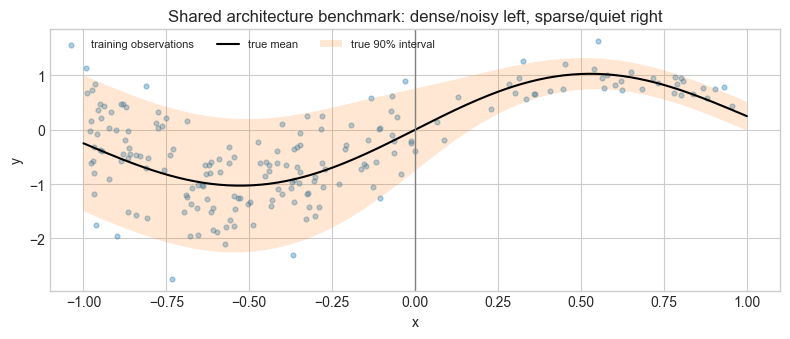

In [4]:
def normal_truth(x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    loc = 0.9 * torch.sin(math.pi * x) + 0.25 * x
    scale = 0.16 + 0.60 * torch.sigmoid(-7.0 * x)
    raw = torch.stack([loc, inverse_softplus(scale)], dim=-1)
    return loc, scale, raw

n_left = round(0.8 * N_TRAIN)
x_train = torch.cat([
    torch.empty(n_left).uniform_(-1.0, 0.0),
    torch.empty(N_TRAIN - n_left).uniform_(0.0, 1.0),
]).sort().values
x_test = torch.linspace(-1.0, 1.0, N_TEST)
truth_loc_train, truth_scale_train, raw_train = normal_truth(x_train)
truth_loc_test, truth_scale_test, raw_test = normal_truth(x_test)
normal_family = db.NormalFamily()
y_train = normal_family(raw_train).sample()
y_test = normal_family(raw_test).sample()
X_train = {'x': x_train[:, None]}
X_test = {'x': x_test[:, None]}

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.scatter(x_train, y_train, s=12, alpha=0.35, label='training observations')
ax.plot(x_test, truth_loc_test, color='black', label='true mean')
ax.fill_between(
    x_test, truth_loc_test - 1.645 * truth_scale_test,
    truth_loc_test + 1.645 * truth_scale_test, alpha=0.18, label='true 90% interval'
)
ax.axvline(0, color='0.5', lw=1)
ax.set(title='Shared architecture benchmark: dense/noisy left, sparse/quiet right', xlabel='x', ylabel='y')
ax.legend(ncol=3, fontsize=8)
fig.tight_layout()

In [5]:
shape_names = ['BayesianMLP', 'NeuralLinearMLP', 'MLP', 'ResNet']
shape_models, shape_histories, shape_draws, shape_predictive_samples = {}, {}, {}, {}
shape_rows = []

for index, shape_name in enumerate(shape_names):
    model = make_shape_model(shape_name, normal_family, N_TRAIN)
    history, seconds = fit_model(model, X_train, y_train, seed=SEED + index)
    metrics, draws, predictive_samples = score_model(model, X_test, y_test, raw_test)
    components = db.variance_decomposition(model, draws.summed_samples)
    left, right = x_test < 0, x_test > 0
    metrics.update({
        'model': shape_name,
        'has_weight_posterior': shape_name in {'BayesianMLP', 'NeuralLinearMLP'},
        'seconds': seconds,
        'parameters': sum(p.numel() for p in model.parameters()),
        'final_loss': history['loss'][-1],
        'aleatoric_truth_corr': float(np.corrcoef(
            components.aleatoric.numpy(), truth_scale_test.square().numpy()
        )[0, 1]) if components.aleatoric.std() > 0 else np.nan,
        'epistemic_sparse_dense_ratio': float(
            components.epistemic[right].mean() / (components.epistemic[left].mean() + 1e-8)
        ),
    })
    shape_rows.append(metrics)
    shape_models[shape_name] = model
    shape_histories[shape_name] = history
    shape_draws[shape_name] = draws
    shape_predictive_samples[shape_name] = predictive_samples

shape_scorecard = add_review_flags(pd.DataFrame(shape_rows).set_index('model'))
shape_scorecard.sort_values('crps').round(3)

,nll,crps,predictive_coverage_90,predictive_width_90,pit_ks,raw_parameter_rmse,raw_parameter_coverage_90,has_weight_posterior,seconds,parameters,final_loss,aleatoric_truth_corr,epistemic_sparse_dense_ratio,predictive_review,uncertainty_review
model,,,,,,,,,,,,,,,
MLP,0.507,0.256,0.867,1.357,0.047,0.169,0.000,False,0.037,338,0.692,0.930,0.000,looks reasonable,point estimate
ResNet,0.627,0.259,0.842,1.336,0.089,0.222,0.000,False,0.052,1154,0.683,0.938,0.000,looks reasonable,point estimate
NeuralLinearMLP,0.570,0.266,0.900,1.561,0.041,0.235,0.554,True,0.051,372,1.091,0.935,1.329,looks reasonable,investigate
BayesianMLP,0.679,0.279,0.950,1.902,0.090,0.404,0.742,True,0.124,676,3.224,0.942,1.040,looks reasonable,investigate


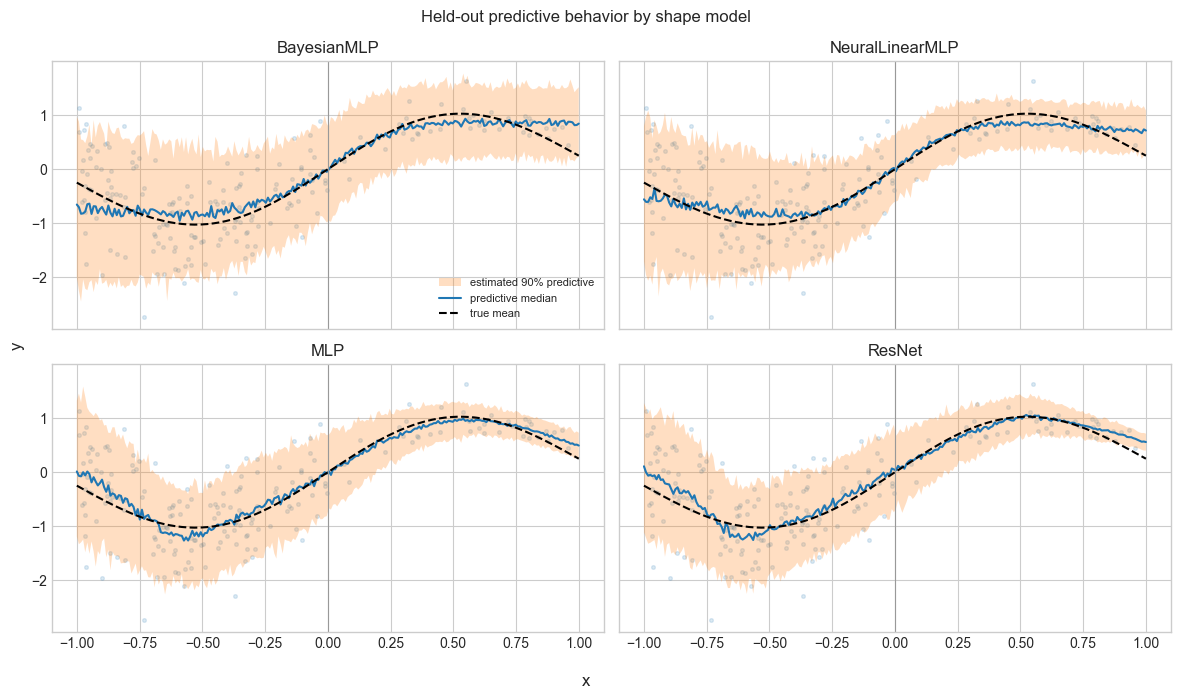

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True, sharey=True)
for ax, shape_name in zip(axes.flat, shape_names, strict=True):
    samples = shape_predictive_samples[shape_name]
    lo, mid, hi = samples.quantile(torch.tensor([0.05, 0.50, 0.95]), dim=0)
    ax.scatter(x_train, y_train, s=7, alpha=0.15)
    ax.fill_between(x_test, lo, hi, alpha=0.25, label='estimated 90% predictive')
    ax.plot(x_test, mid, label='predictive median')
    ax.plot(x_test, truth_loc_test, 'k--', label='true mean')
    ax.set_title(shape_name)
    ax.axvline(0, color='0.6', lw=0.8)
axes[0, 0].legend(fontsize=8)
fig.suptitle('Held-out predictive behavior by shape model')
fig.supxlabel('x'); fig.supylabel('y'); fig.tight_layout()

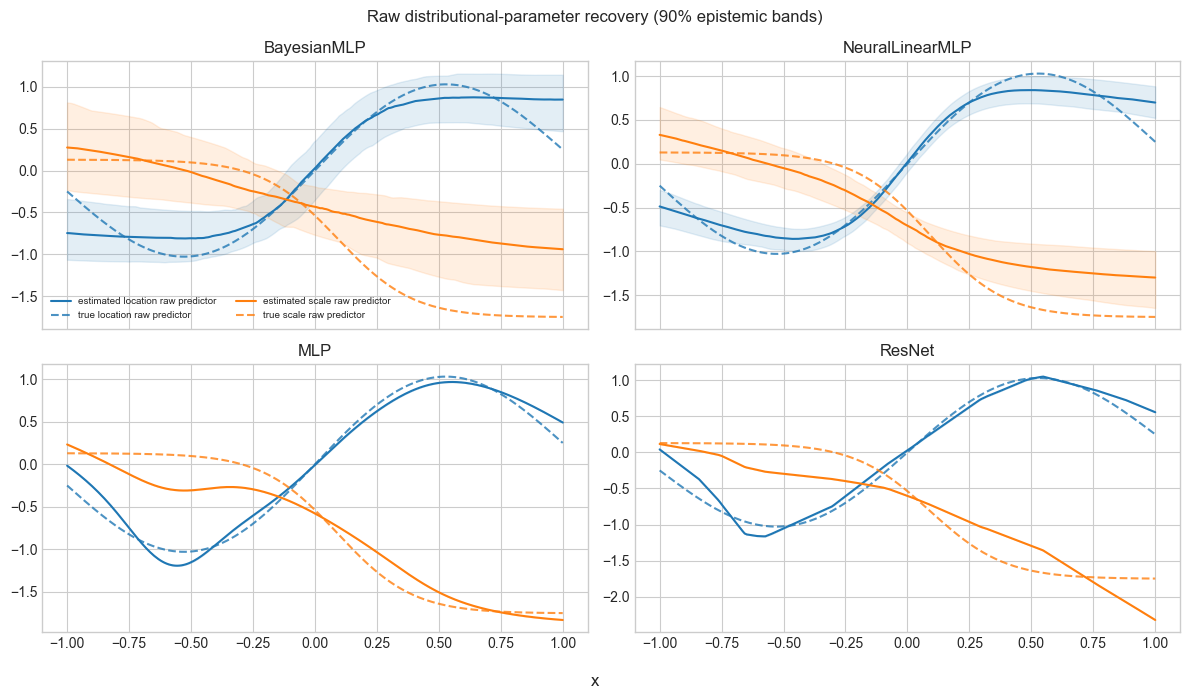

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
for ax, shape_name in zip(axes.flat, shape_names, strict=True):
    draws = shape_draws[shape_name].summed_samples
    for parameter_index, (label, truth, color) in enumerate([
        ('location raw predictor', raw_test[:, 0], 'tab:blue'),
        ('scale raw predictor', raw_test[:, 1], 'tab:orange'),
    ]):
        lo, mid, hi = draws[..., parameter_index].quantile(torch.tensor([0.05, 0.5, 0.95]), dim=0)
        ax.fill_between(x_test, lo, hi, alpha=0.12, color=color)
        ax.plot(x_test, mid, color=color, label=f'estimated {label}')
        ax.plot(x_test, truth, '--', color=color, alpha=0.8, label=f'true {label}')
    ax.set_title(shape_name)
axes[0, 0].legend(fontsize=7, ncol=2)
fig.suptitle('Raw distributional-parameter recovery (90% epistemic bands)')
fig.supxlabel('x'); fig.tight_layout()

### Information criteria

WAIC is shown for all four fitted models. PSIS-LOO is intentionally not used as a universal ranking here: deterministic baselines have identical importance weights, and reliable tail diagnostics need substantially more posterior draws than quick review mode uses. Held-out NLL and CRPS above remain the primary comparison.

In [8]:
waic_rows = []
for shape_name, model in shape_models.items():
    result = db.waic(model, X_test, y_test, T=DRAWS)
    waic_rows.append({
        'model': shape_name, 'elpd_waic': result.elpd,
        'p_waic': result.p, 'se': result.se, 'draws': result.n_samples,
    })
pd.DataFrame(waic_rows).set_index('model').sort_values('elpd_waic', ascending=False).round(2)

,elpd_waic,p_waic,se,draws
model,,,,
MLP,-121.70,0.00,18.08,160
ResNet,-150.42,0.00,20.63,160
NeuralLinearMLP,-162.38,25.10,14.85,160
BayesianMLP,-232.75,70.97,17.12,160


## Results 2 — all implemented response families

Each family gets a support-appropriate nonlinear truth. Scores are comparable **within a family or against future versions of that family**, not across families: CRPS and NLL have different scales when the outcome support and magnitude change.

In [9]:
@dataclass
class FamilyScenario:
    name: str
    family: db.BaseFamily
    parameter_names: tuple[str, ...]
    raw_truth_fn: object
    discrete: bool = False


def raw_normal(x):
    return torch.stack([0.8 * torch.sin(math.pi * x), inverse_softplus(0.25 + 0.2 * (x + 1) / 2)], -1)

def raw_student_t(x):
    return torch.stack([0.8 * torch.sin(math.pi * x), inverse_softplus(0.30 + 0.10 * x.square()), inverse_softplus(3.5 + 0.8 * x)], -1)

def raw_gamma(x):
    concentration = 2.2 + 1.0 * torch.sigmoid(3 * x)
    rate = 1.0 + 0.5 * torch.cos(math.pi * x)
    return torch.stack([inverse_softplus(concentration), inverse_softplus(rate)], -1)

def raw_johnson(x):
    skew = 0.7 * torch.sin(math.pi * x)
    tail = 1.5 + 0.3 * torch.cos(math.pi * x)
    loc = 0.6 * x
    scale = 0.35 + 0.10 * (x + 1)
    return torch.stack([skew, inverse_softplus(tail), loc, inverse_softplus(scale)], -1)

def raw_negative_binomial(x):
    mu = 2.0 + 5.0 * torch.sigmoid(3 * x)
    dispersion = 0.18 + 0.25 * (x + 1) / 2
    return torch.stack([inverse_softplus(mu), inverse_softplus(dispersion)], -1)

def raw_beta(x):
    mu = 0.15 + 0.70 * torch.sigmoid(2.5 * x)
    precision = 10.0 + 12.0 * torch.cos(math.pi * x / 2).square()
    return torch.stack([logit(mu), inverse_softplus(precision)], -1)


scenarios = [
    FamilyScenario('Normal', db.NormalFamily(), ('location', 'scale'), raw_normal),
    FamilyScenario('StudentT', db.StudentTFamily(df_min=2.0), ('location', 'scale', 'df'), raw_student_t),
    FamilyScenario('Gamma', db.GammaFamily(), ('concentration', 'rate'), raw_gamma),
    FamilyScenario('JohnsonSU', db.JohnsonSUFamily(), ('skew', 'tail', 'location', 'scale'), raw_johnson),
    FamilyScenario('NegativeBinomial', db.NegativeBinomialFamily(), ('mean', 'dispersion'), raw_negative_binomial, True),
    FamilyScenario('Beta', db.BetaFamily(), ('mean', 'precision'), raw_beta),
]
[(s.name, s.family.param_count, s.parameter_names) for s in scenarios]

[('Normal', 2, ('location', 'scale')),
 ('StudentT', 3, ('location', 'scale', 'df')),
 ('Gamma', 2, ('concentration', 'rate')),
 ('JohnsonSU', 4, ('skew', 'tail', 'location', 'scale')),
 ('NegativeBinomial', 2, ('mean', 'dispersion')),
 ('Beta', 2, ('mean', 'precision'))]

In [10]:
family_models, family_draws, family_samples, family_data = {}, {}, {}, {}
family_rows = []

for index, scenario in enumerate(scenarios):
    db.seed_everything(SEED + 100 + index)
    x_fit = torch.empty(N_TRAIN).uniform_(-1.0, 1.0).sort().values
    x_holdout = torch.linspace(-1.0, 1.0, N_TEST)
    raw_fit = scenario.raw_truth_fn(x_fit)
    raw_holdout = scenario.raw_truth_fn(x_holdout)
    y_fit = scenario.family(raw_fit).sample()
    y_holdout = scenario.family(raw_holdout).sample()
    model = make_shape_model('BayesianMLP', scenario.family, N_TRAIN)
    history, seconds = fit_model(model, {'x': x_fit[:, None]}, y_fit, seed=SEED + 100 + index)
    metrics, draws, samples = score_model(
        model, {'x': x_holdout[:, None]}, y_holdout, raw_holdout,
        discrete=scenario.discrete,
    )
    metrics.update({
        'family': scenario.name, 'has_weight_posterior': True, 'seconds': seconds,
        'parameters': sum(p.numel() for p in model.parameters()),
        'final_loss': history['loss'][-1],
    })
    family_rows.append(metrics)
    family_models[scenario.name] = model
    family_draws[scenario.name] = draws
    family_samples[scenario.name] = samples
    family_data[scenario.name] = (x_fit, y_fit, x_holdout, y_holdout, raw_holdout)

family_scorecard = add_review_flags(pd.DataFrame(family_rows).set_index('family'))
family_scorecard.round(3)

,nll,crps,predictive_coverage_90,predictive_width_90,pit_ks,raw_parameter_rmse,raw_parameter_coverage_90,has_weight_posterior,seconds,parameters,final_loss,predictive_review,uncertainty_review
family,,,,,,,,,,,,,
Normal,0.585,0.237,0.958,1.782,0.086,0.342,0.573,True,0.097,676,2.944,looks reasonable,investigate
StudentT,0.803,0.298,0.954,2.091,0.061,1.415,0.474,True,0.099,710,3.146,looks reasonable,investigate
Gamma,2.059,1.245,0.908,7.052,0.103,1.093,0.181,True,0.092,676,4.249,looks reasonable,investigate
JohnsonSU,0.652,0.281,0.913,1.714,0.072,0.337,0.773,True,0.093,744,3.171,looks reasonable,looks reasonable
NegativeBinomial,2.421,1.750,0.925,9.470,0.057,0.550,0.975,True,0.106,676,4.600,looks reasonable,looks reasonable
Beta,-0.677,0.070,0.967,0.486,0.081,5.268,0.575,True,0.100,676,1.676,looks reasonable,investigate


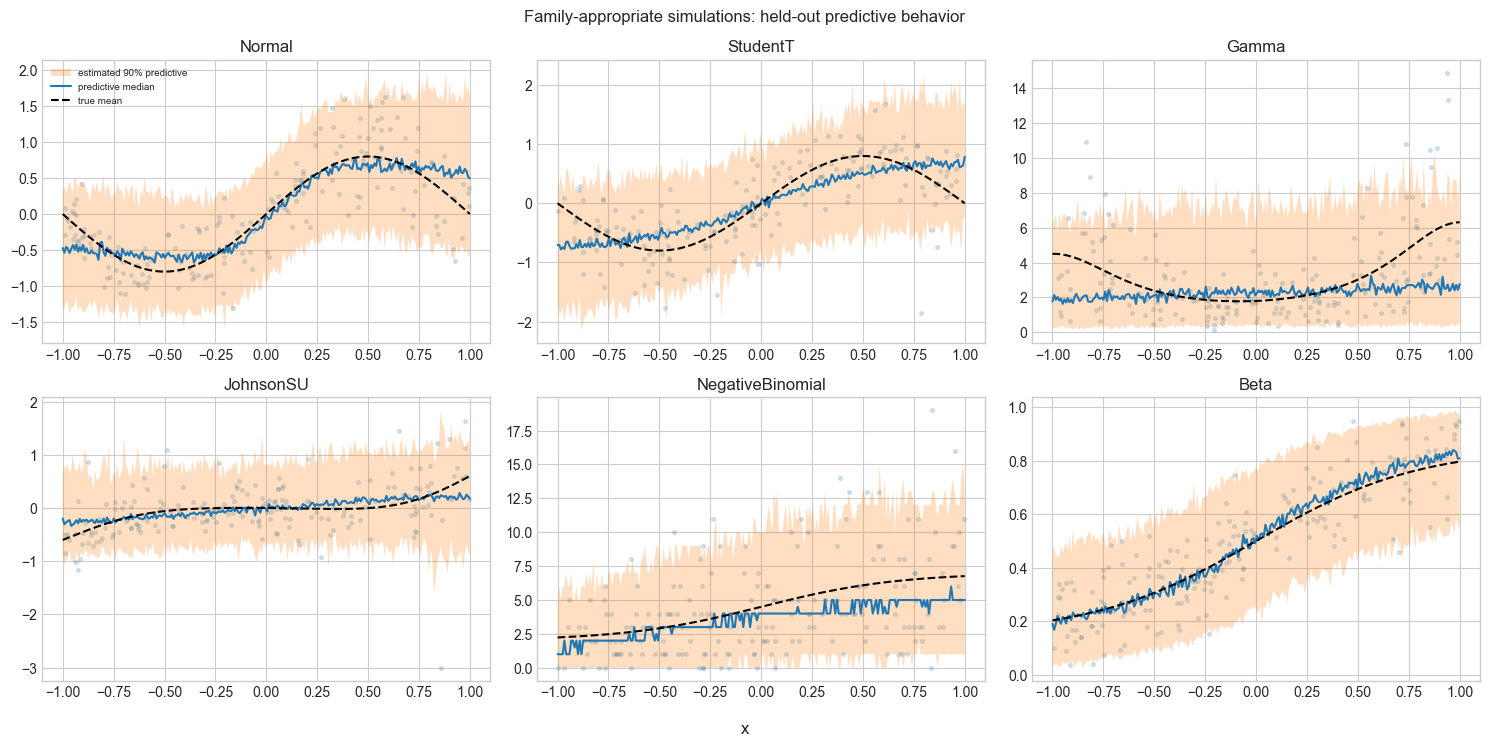

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7.5))
for ax, scenario in zip(axes.flat, scenarios, strict=True):
    x_fit, y_fit, x_holdout, y_holdout, _ = family_data[scenario.name]
    samples = family_samples[scenario.name].float()
    lo, mid, hi = samples.quantile(torch.tensor([0.05, 0.5, 0.95]), dim=0)
    true_mean = scenario.family(scenario.raw_truth_fn(x_holdout)).mean
    ax.scatter(x_fit, y_fit, s=7, alpha=0.18)
    ax.fill_between(x_holdout, lo, hi, alpha=0.25, label='estimated 90% predictive')
    ax.plot(x_holdout, mid, label='predictive median')
    ax.plot(x_holdout, true_mean, 'k--', label='true mean')
    ax.set_title(scenario.name)
axes[0, 0].legend(fontsize=7)
fig.suptitle('Family-appropriate simulations: held-out predictive behavior')
fig.supxlabel('x'); fig.tight_layout()

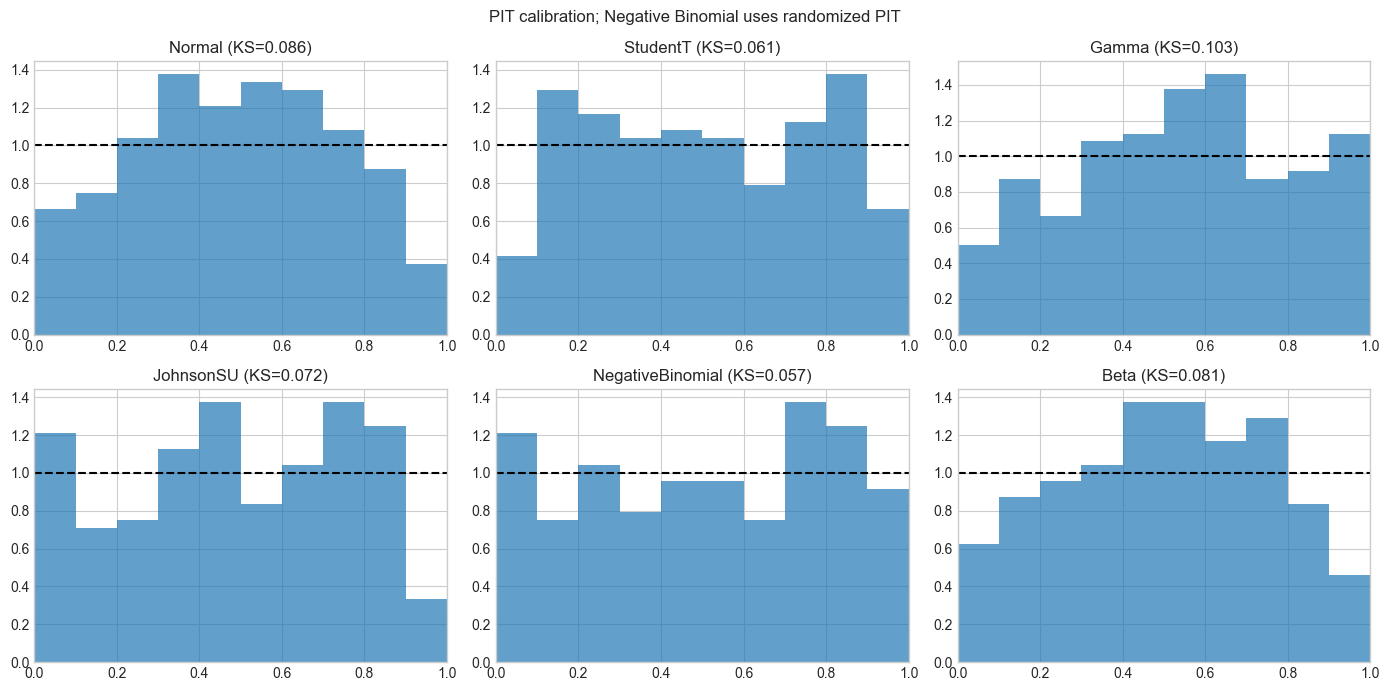

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, scenario in zip(axes.flat, scenarios, strict=True):
    _, _, x_holdout, _, _ = family_data[scenario.name]
    values = db.pit(
        scenario.family, family_draws[scenario.name].summed_samples,
        family_data[scenario.name][3], randomized=scenario.discrete, seed=SEED,
    ).numpy()
    ax.hist(values, bins=10, range=(0, 1), density=True, alpha=0.7)
    ax.axhline(1.0, color='black', ls='--')
    ax.set(title=f"{scenario.name} (KS={stats.kstest(values, 'uniform').statistic:.3f})", xlim=(0, 1))
fig.suptitle('PIT calibration; Negative Binomial uses randomized PIT')
fig.tight_layout()

## Results 3 — interaction recovery

A pure two-dimensional interaction checks the formula parser, joint network, coherent effect sampling, and surface recovery together. The raw location effect is identifiable only up to a constant, so truth and every posterior draw are centered before comparison.

In [13]:
db.seed_everything(SEED + 300)
x1_int = torch.empty(N_TRAIN).uniform_(-1, 1)
x2_int = torch.empty(N_TRAIN).uniform_(-1, 1)
truth_int = torch.sin(math.pi * x1_int) * x2_int
scale_int = torch.full_like(truth_int, 0.22)
raw_int = torch.stack([truth_int, inverse_softplus(scale_int)], -1)
y_int = db.NormalFamily()(raw_int).sample()
model_int = db.BayesianNAMLSS.from_formula(
    f"y ~ BayesianMLP(x1, hidden_dims={tuple(HIDDEN_DIMS)}, activation='tanh'):BayesianMLP(x2)",
    family=db.NormalFamily(), n_obs=N_TRAIN,
)
history_int, seconds_int = fit_model(
    model_int, {'x1': x1_int[:, None], 'x2': x2_int[:, None]}, y_int, seed=SEED + 300
)
grid_axis = torch.linspace(-1, 1, 30 if QUICK_MODE else 50)
g1, g2 = torch.meshgrid(grid_axis, grid_axis, indexing='xy')
grid_joint = torch.stack([g1.ravel(), g2.ravel()], dim=-1)
interaction_draws = sample_effects(
    model_int, {'x1:x2': grid_joint}, T=DRAWS
)['x1:x2'][..., 0]
interaction_draws = interaction_draws - interaction_draws.mean(dim=1, keepdim=True)
truth_surface = torch.sin(math.pi * grid_joint[:, 0]) * grid_joint[:, 1]
truth_surface = truth_surface - truth_surface.mean()
surface_mid = interaction_draws.median(dim=0).values
interaction_rmse = torch.sqrt(((surface_mid - truth_surface) ** 2).mean())
interaction_coverage = db.quantile_coverage(
    interaction_draws[..., None], truth_surface[:, None], levels=(0.9,)
).coverage.item()
pd.Series({
    'centered_surface_rmse': float(interaction_rmse),
    'epistemic_coverage_90': interaction_coverage,
    'seconds': seconds_int, 'final_loss': history_int['loss'][-1],
}).round(3)

centered_surface_rmse    0.231
epistemic_coverage_90    0.742
seconds                  0.089
final_loss               3.000
dtype: float64

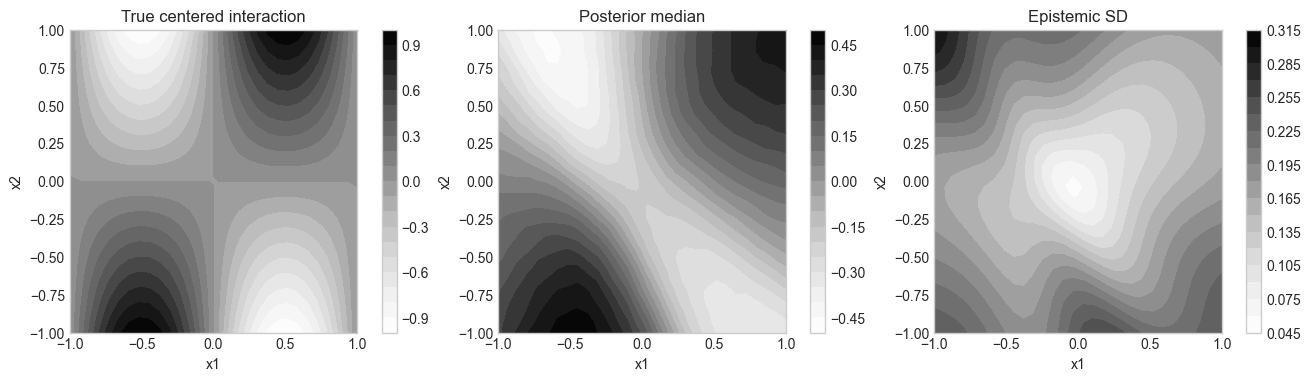

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.7), constrained_layout=True)
surfaces = [
    ('True centered interaction', truth_surface),
    ('Posterior median', surface_mid),
    ('Epistemic SD', interaction_draws.std(dim=0)),
]
for ax, (title, values) in zip(axes, surfaces, strict=True):
    image = ax.contourf(g1, g2, values.reshape(g1.shape), levels=20)
    fig.colorbar(image, ax=ax)
    ax.set(title=title, xlabel='x1', ylabel='x2')

## Results 4 — categorical partial pooling

The category counts deliberately fall from 120 to 5. A useful Bayesian embedding should generally express greater uncertainty for rare levels and shrink weakly identified effects toward the shared prior. This is a qualitative stress test: one draw cannot prove a universal count-to-width relationship.

In [15]:
db.seed_everything(SEED + 400)
groups = list('ABCDEFGH')
sizes = [120, 90, 60, 40, 25, 15, 8, 5]
true_group_effects = torch.tensor([-0.8, -0.4, 0.2, 0.75, 0.45, -0.2, 0.9, -0.7])
group_index = torch.cat([torch.full((size,), i) for i, size in enumerate(sizes)])
x_cat = torch.empty(group_index.numel()).uniform_(-1, 1)
raw_loc_cat = true_group_effects[group_index] + 0.5 * x_cat
raw_cat = torch.stack([raw_loc_cat, inverse_softplus(torch.full_like(raw_loc_cat, 0.3))], -1)
y_cat = db.NormalFamily()(raw_cat).sample()
n_cat = len(y_cat)
family_cat = db.NormalFamily()
model_cat = db.BayesianNAMLSS(
    {
        'x': BayesianMLP(1, 2, hidden_dims=HIDDEN_DIMS, kl_divisor=n_cat, activation='tanh'),
        'group': BayesianEmbedding(len(groups), 2, kl_divisor=n_cat),
    },
    family=family_cat, n_obs=n_cat,
)
history_cat, seconds_cat = fit_model(
    model_cat, {'x': x_cat[:, None], 'group': group_index}, y_cat,
    seed=SEED + 400, epochs=EPOCHS,
)
level_draws = sample_effects(
    model_cat, {'x': torch.zeros(1, 1), 'group': torch.arange(len(groups))}, T=DRAWS
)['group'][..., 0]
level_draws = level_draws - level_draws.mean(dim=1, keepdim=True)
truth_group_centered = true_group_effects - true_group_effects.mean()
lo, mid, hi = level_draws.quantile(torch.tensor([0.05, 0.5, 0.95]), dim=0)
categorical_summary = pd.DataFrame({
    'group': groups, 'n': sizes, 'truth': truth_group_centered.numpy(),
    'posterior_median': mid.numpy(), 'lower_90': lo.numpy(), 'upper_90': hi.numpy(),
    'interval_width': (hi - lo).numpy(),
})
categorical_summary.round(3)

,group,n,truth,posterior_median,lower_90,upper_90,interval_width
0,A,120,-0.825,-0.804,-0.869,-0.739,0.131
1,B,90,-0.425,-0.432,-0.506,-0.363,0.143
2,C,60,0.175,0.246,0.172,0.306,0.134
3,D,40,0.725,0.685,0.605,0.776,0.171
4,E,25,0.425,0.421,0.328,0.548,0.220
5,F,15,-0.225,-0.104,-0.238,0.027,0.265
6,G,8,0.875,0.805,0.583,0.970,0.387
7,H,5,-0.725,-0.803,-0.948,-0.652,0.296


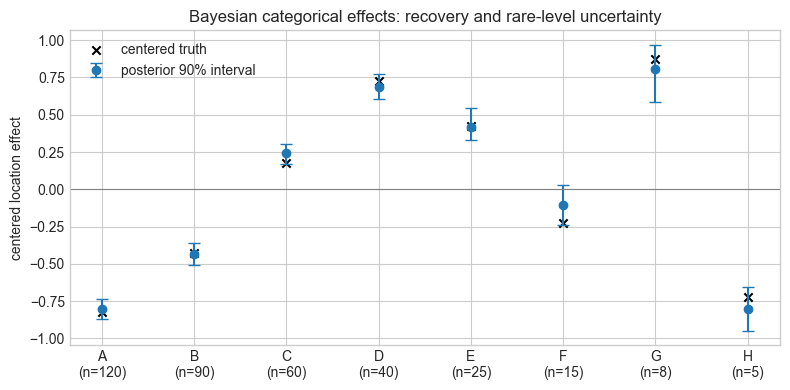

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
positions = np.arange(len(groups))
ax.errorbar(
    positions, mid, yerr=[(mid - lo).numpy(), (hi - mid).numpy()],
    fmt='o', capsize=4, label='posterior 90% interval',
)
ax.scatter(positions, truth_group_centered, marker='x', color='black', label='centered truth')
ax.axhline(0, color='0.5', lw=0.8)
ax.set_xticks(positions, [f'{group}\n(n={size})' for group, size in zip(groups, sizes, strict=True)])
ax.set(title='Bayesian categorical effects: recovery and rare-level uncertainty', ylabel='centered location effect')
ax.legend(); fig.tight_layout()

## Checks — repeated-seed sensitivity

A single seed is excellent for finding obvious problems and poor for estimating frequentist coverage. The optional block below repeats the Normal `BayesianMLP` benchmark and summarizes variation. Enable it before using this notebook to make a consequential calibration claim.

In [17]:
repeated_rows = []
if RUN_REPEATED_SEEDS:
    for repeat_seed in range(SEED, SEED + (3 if QUICK_MODE else 10)):
        db.seed_everything(repeat_seed)
        x_rep = torch.empty(N_TRAIN).uniform_(-1, 1)
        _, _, raw_rep = normal_truth(x_rep)
        y_rep = normal_family(raw_rep).sample()
        model_rep = make_shape_model('BayesianMLP', normal_family, N_TRAIN)
        _, _ = fit_model(model_rep, {'x': x_rep[:, None]}, y_rep, seed=repeat_seed)
        metrics_rep, _, _ = score_model(model_rep, X_test, y_test, raw_test)
        metrics_rep['seed'] = repeat_seed
        repeated_rows.append(metrics_rep)
    repeated_results = pd.DataFrame(repeated_rows).set_index('seed')
    display(repeated_results.round(3))
    display(repeated_results.agg(['mean', 'std', 'min', 'max']).round(3))
else:
    print('Skipped. Set RUN_REPEATED_SEEDS=True for seed-sensitivity evidence.')

Skipped. Set RUN_REPEATED_SEEDS=True for seed-sensitivity evidence.


## Takeaways and manual decision guide

Use the executed outputs above in this order:

1. **Rule out optimization failures.** Inspect final loss, non-finite metrics, predictive plots, and gross truth mismatch.
2. **Judge predictive usefulness.** Prefer held-out CRPS and NLL; then check that coverage was not bought with needlessly wide intervals.
3. **Judge calibration.** PIT shape and predictive coverage diagnose the whole predictive distribution. Raw-parameter coverage diagnoses the variational posterior and is expected to expose mean-field narrowness.
4. **Judge the scientific claim.** In the shared Normal benchmark, aleatoric variance should track the known noise curve while epistemic variance should generally rise in the sparse region.
5. **Localize improvements.** A failure shared by every shape model points toward training, links, or evaluation. A failure isolated to one family points toward its parameterization or optimization. A Bayesian-only failure points toward the variational approximation, prior, or KL schedule.
6. **Repeat before committing.** Re-run suspicious cases with `QUICK_MODE=False`, `RUN_REPEATED_SEEDS=True`, and several learning rates. Treat a one-seed threshold flag as an invitation to inspect, not a verdict.

### Candidate improvement experiments

- Tune prior scale and KL warm-up before increasing network width.
- Compare fully variational and last-layer-only models at matched runtime.
- For under-coverage, quantify the gap across seeds; do not silently inflate bands.
- For Johnson SU instability, inspect tailweight trajectories and moment finiteness.
- For rare categories, plot interval width against level count over repeated simulations.
- Use PSIS-LOO only with enough posterior draws to inspect Pareto-k reliability.